## Import Required Libraries

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from minisom import MiniSom

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test


## Project Folder Paths

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

CLUSTERING_DIR = PROJECT_ROOT / "results" / "module_2" / "clustering"
EVALUATION_DIR = PROJECT_ROOT / "results" / "module_2" / "evaluation"
PLOTS_DIR = PROJECT_ROOT / "plots" / "module_2" / "evaluation"

EVALUATION_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Clustering results:", CLUSTERING_DIR)
print("Evaluation results:", EVALUATION_DIR)
print("Evaluation plots:", PLOTS_DIR)

Project root: C:\Users\samsa\Documents\ICU Clustering
Clustering results: C:\Users\samsa\Documents\ICU Clustering\results\module_2\clustering
Evaluation results: C:\Users\samsa\Documents\ICU Clustering\results\module_2\evaluation
Evaluation plots: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation


## Load t-SNE Results

In [3]:
tsne_embedding = pd.read_csv(CLUSTERING_DIR / "tsne_embedding.csv")
tsne_clusters = pd.read_csv(CLUSTERING_DIR / "tsne_dbscan_clusters.csv")

print("t-SNE embedding shape:", tsne_embedding.shape)
print("t-SNE embedding columns:", tsne_embedding.columns.tolist())

print("\nt-SNE cluster shape:", tsne_clusters.shape)
print("t-SNE cluster columns:", tsne_clusters.columns.tolist())

t-SNE embedding shape: (7648, 3)
t-SNE embedding columns: ['patientunitstayid', 'tsne_1', 'tsne_2']

t-SNE cluster shape: (7648, 4)
t-SNE cluster columns: ['patientunitstayid', 'tsne_1', 'tsne_2', 'cluster']


## Check t-SNE Cluster Distribution

In [4]:
cluster_counts = tsne_clusters["cluster"].value_counts().sort_index()

print("Cluster counts:")
print(cluster_counts)

print("\nNumber of outliers:", (tsne_clusters["cluster"] == -1).sum())
print("Number of regular clusters:", tsne_clusters.loc[
    tsne_clusters["cluster"] != -1, "cluster"
].nunique())

Cluster counts:
cluster
-1      445
 0      363
 1     2060
 2     2128
 3      347
 4       87
 5      173
 6      227
 7      170
 8      223
 9       65
 10      77
 11      67
 12     128
 13      66
 14      64
 15     119
 16      58
 17      55
 18     117
 19     130
 20     230
 21     192
 22      57
Name: count, dtype: int64

Number of outliers: 445
Number of regular clusters: 23


## Remove t-SNE Outliers for Evaluation

In [5]:
tsne_eval = tsne_clusters[tsne_clusters["cluster"] != -1].copy()

print("Patients before removing outliers:", len(tsne_clusters))
print("Patients used for evaluation:", len(tsne_eval))
print("Outliers removed:", len(tsne_clusters) - len(tsne_eval))

Patients before removing outliers: 7648
Patients used for evaluation: 7203
Outliers removed: 445


## Calculate t-SNE Silhouette Score

In [6]:
X_tsne = tsne_eval[["tsne_1", "tsne_2"]]
labels_tsne = tsne_eval["cluster"]

tsne_silhouette = silhouette_score(X_tsne, labels_tsne)

print("t-SNE + DBSCAN Silhouette Score:", round(tsne_silhouette, 4))

t-SNE + DBSCAN Silhouette Score: 0.5534


## Calculate t-SNE Davies-Bouldin Index

In [7]:
tsne_dbi = davies_bouldin_score(X_tsne, labels_tsne)

print("t-SNE + DBSCAN Davies-Bouldin Index:", round(tsne_dbi, 4))

t-SNE + DBSCAN Davies-Bouldin Index: 0.3425


## Calculate t-SNE Calinski-Harabasz Index

In [8]:
tsne_chi = calinski_harabasz_score(X_tsne, labels_tsne)

print("t-SNE + DBSCAN Calinski-Harabasz Index:", round(tsne_chi, 2))

t-SNE + DBSCAN Calinski-Harabasz Index: 4632.03


## Load UMAP Results

In [9]:
umap_clusters = pd.read_csv(
    CLUSTERING_DIR / "umap_dbscan_clusters.csv"
)

print("UMAP cluster shape:", umap_clusters.shape)
print("UMAP cluster columns:", umap_clusters.columns.tolist())

UMAP cluster shape: (7648, 4)
UMAP cluster columns: ['patientunitstayid', 'umap_1', 'umap_2', 'cluster']


## Check UMAP Cluster Distribution

In [10]:
umap_cluster_counts = umap_clusters["cluster"].value_counts().sort_index()

print("Cluster counts:")
print(umap_cluster_counts)

print("\nNumber of outliers:", (umap_clusters["cluster"] == -1).sum())
print(
    "Number of regular clusters:",
    umap_clusters.loc[umap_clusters["cluster"] != -1, "cluster"].nunique()
)

Cluster counts:
cluster
-1      513
 0      363
 1     2060
 2     2128
 3      345
 4       87
 5      173
 6      227
 7      170
 8      223
 9       69
 10      75
 11      54
 12     126
 13      58
 14      69
 15      64
 16     120
 17      55
 18     110
 19     137
 20     230
 21     192
Name: count, dtype: int64

Number of outliers: 513
Number of regular clusters: 22


## Remove UMAP Outliers

In [11]:
umap_eval = umap_clusters[umap_clusters["cluster"] != -1].copy()

print("Patients before removing outliers:", len(umap_clusters))
print("Patients used for evaluation:", len(umap_eval))
print("Outliers removed:", len(umap_clusters) - len(umap_eval))

Patients before removing outliers: 7648
Patients used for evaluation: 7135
Outliers removed: 513


## UMAP Silhouette Score

In [12]:
X_umap = umap_eval[["umap_1", "umap_2"]]
labels_umap = umap_eval["cluster"]

umap_silhouette = silhouette_score(X_umap, labels_umap)

print("UMAP + DBSCAN Silhouette Score:", round(umap_silhouette, 4))

UMAP + DBSCAN Silhouette Score: 0.8866


## UMAP Davies-Bouldin Index

In [13]:
umap_dbi = davies_bouldin_score(X_umap, labels_umap)

print("UMAP + DBSCAN Davies-Bouldin Index:", round(umap_dbi, 4))

UMAP + DBSCAN Davies-Bouldin Index: 0.0906


## UMAP Calinski-Harabasz Index

In [14]:
umap_chi = calinski_harabasz_score(X_umap, labels_umap)

print("UMAP + DBSCAN Calinski-Harabasz Index:", round(umap_chi, 2))

UMAP + DBSCAN Calinski-Harabasz Index: 72279.12


## Load VAE Results

In [15]:
vae_clusters = pd.read_csv(
    CLUSTERING_DIR / "vae_dbscan_clusters.csv"
)

print("VAE cluster shape:", vae_clusters.shape)
print("VAE cluster columns:", vae_clusters.columns.tolist())

VAE cluster shape: (7648, 4)
VAE cluster columns: ['patientunitstayid', 'vae_1', 'vae_2', 'cluster']


## Check VAE Cluster Distribution

In [16]:
vae_cluster_counts = vae_clusters["cluster"].value_counts().sort_index()

print("Cluster counts:")
print(vae_cluster_counts)

print("\nNumber of outliers:", (vae_clusters["cluster"] == -1).sum())
print(
    "Number of regular clusters:",
    vae_clusters.loc[vae_clusters["cluster"] != -1, "cluster"].nunique()
)

Cluster counts:
cluster
-1      111
 0      360
 1     2060
 2     2128
 3      345
 4       87
 5      454
 6      321
 7      170
 8     1496
 9       61
 10      55
Name: count, dtype: int64

Number of outliers: 111
Number of regular clusters: 11


## Remove VAE Outliers

In [17]:
vae_eval = vae_clusters[vae_clusters["cluster"] != -1].copy()

print("Patients before removing outliers:", len(vae_clusters))
print("Patients used for evaluation:", len(vae_eval))
print("Outliers removed:", len(vae_clusters) - len(vae_eval))

Patients before removing outliers: 7648
Patients used for evaluation: 7537
Outliers removed: 111


## VAE Silhouette Score

In [18]:
X_vae = vae_eval[["vae_1", "vae_2"]]
labels_vae = vae_eval["cluster"]

vae_silhouette = silhouette_score(X_vae, labels_vae)

print("VAE + DBSCAN Silhouette Score:", round(vae_silhouette, 4))

VAE + DBSCAN Silhouette Score: 0.4326


## VAE Davies-Bouldin Index

In [19]:
vae_dbi = davies_bouldin_score(X_vae, labels_vae)

print("VAE + DBSCAN Davies-Bouldin Index:", round(vae_dbi, 4))

VAE + DBSCAN Davies-Bouldin Index: 0.623


## VAE Calinski-Harabasz Index 

In [20]:
vae_chi = calinski_harabasz_score(X_vae, labels_vae)

print("VAE + DBSCAN Calinski-Harabasz Index:", round(vae_chi, 2))

VAE + DBSCAN Calinski-Harabasz Index: 4235.76


## Create and save the internal evaluation table

In [21]:
internal_metrics = pd.DataFrame({
    "method": ["t-SNE + DBSCAN", "UMAP + DBSCAN", "VAE + DBSCAN"],
    "silhouette_score": [tsne_silhouette, umap_silhouette, vae_silhouette],
    "davies_bouldin_index": [tsne_dbi, umap_dbi, vae_dbi],
    "calinski_harabasz_index": [tsne_chi, umap_chi, vae_chi]
})

internal_metrics.round(4)

,method,silhouette_score,davies_bouldin_index,calinski_harabasz_index
0,t-SNE + DBSCAN,0.5534,0.3425,4632.0257
1,UMAP + DBSCAN,0.8866,0.0906,72279.1192
2,VAE + DBSCAN,0.4326,0.6230,4235.7608


## Save the internal metrics

In [22]:
internal_metrics.to_csv(
    EVALUATION_DIR / "internal_metrics.csv",
    index=False
)

print("Saved:", EVALUATION_DIR / "internal_metrics.csv")

Saved: C:\Users\samsa\Documents\ICU Clustering\results\module_2\evaluation\internal_metrics.csv


## Align cluster assignments by patient

In [23]:
cluster_agreement = (
    tsne_clusters[["patientunitstayid", "cluster"]]
    .rename(columns={"cluster": "tsne_cluster"})
    .merge(
        umap_clusters[["patientunitstayid", "cluster"]]
        .rename(columns={"cluster": "umap_cluster"}),
        on="patientunitstayid"
    )
    .merge(
        vae_clusters[["patientunitstayid", "cluster"]]
        .rename(columns={"cluster": "vae_cluster"}),
        on="patientunitstayid"
    )
)

print("Combined shape:", cluster_agreement.shape)
print(cluster_agreement.head())

Combined shape: (7648, 4)
   patientunitstayid  tsne_cluster  umap_cluster  vae_cluster
0             151900             0             0            0
1             210208            -1            -1           -1
2             179269             1             1            1
3             172764             1             1            1
4             166175             2             2            2


## t-SNE vs UMAP contingency table

In [24]:
tsne_umap_table = pd.crosstab(
    cluster_agreement["tsne_cluster"],
    cluster_agreement["umap_cluster"]
)

display(tsne_umap_table)

umap_cluster,-1,0,1,2,3,4,5,6,7,8,...,12,13,14,15,16,17,18,19,20,21
tsne_cluster,,,,,,,,,,,,,,,,,,,,,
-1,428,0,0,0,0,0,0,0,0,0,...,1,0,3,0,1,0,0,7,0,0
0,0,363,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,2060,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,2128,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2,0,0,0,345,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,87,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,173,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,227,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,170,0,...,0,0,0,0,0,0,0,0,0,0


## t-SNE vs VAE contingency table

In [25]:
tsne_vae_table = pd.crosstab(
    cluster_agreement["tsne_cluster"],
    cluster_agreement["vae_cluster"]
)

display(tsne_vae_table)

vae_cluster,-1,0,1,2,3,4,5,6,7,8,9,10
tsne_cluster,,,,,,,,,,,,
-1,92,0,0,0,0,0,150,20,0,183,0,0
0,3,360,0,0,0,0,0,0,0,0,0,0
1,0,0,2060,0,0,0,0,0,0,0,0,0
2,0,0,0,2128,0,0,0,0,0,0,0,0
3,1,0,0,0,345,0,1,0,0,0,0,0
4,0,0,0,0,0,87,0,0,0,0,0,0
5,0,0,0,0,0,0,173,0,0,0,0,0
6,0,0,0,0,0,0,0,227,0,0,0,0
7,0,0,0,0,0,0,0,0,170,0,0,0


## UMAP vs VAE contingency table

In [26]:
umap_vae_table = pd.crosstab(
    cluster_agreement["umap_cluster"],
    cluster_agreement["vae_cluster"]
)

display(umap_vae_table)

vae_cluster,-1,0,1,2,3,4,5,6,7,8,9,10
umap_cluster,,,,,,,,,,,,
-1,97,0,0,0,0,0,219,20,0,177,0,0
0,3,360,0,0,0,0,0,0,0,0,0,0
1,0,0,2060,0,0,0,0,0,0,0,0,0
2,0,0,0,2128,0,0,0,0,0,0,0,0
3,0,0,0,0,345,0,0,0,0,0,0,0
4,0,0,0,0,0,87,0,0,0,0,0,0
5,0,0,0,0,0,0,173,0,0,0,0,0
6,0,0,0,0,0,0,0,227,0,0,0,0
7,0,0,0,0,0,0,0,0,170,0,0,0


## Save the three contingency tables

In [27]:
tsne_umap_table.to_csv(EVALUATION_DIR / "tsne_umap_contingency.csv")
tsne_vae_table.to_csv(EVALUATION_DIR / "tsne_vae_contingency.csv")
umap_vae_table.to_csv(EVALUATION_DIR / "umap_vae_contingency.csv")

print("Contingency tables saved.")

Contingency tables saved.


## t-SNE vs UMAP heatmap

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\tsne_umap_contingency.html


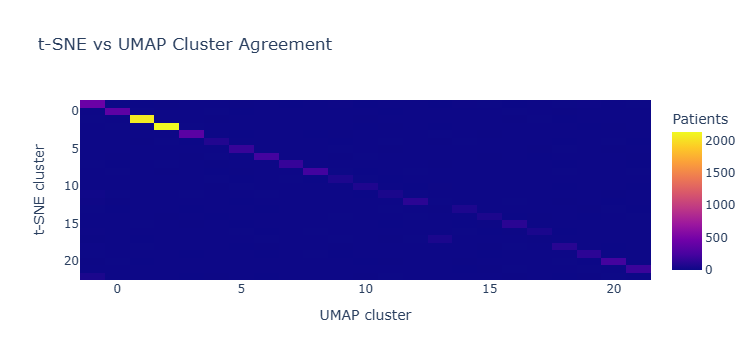

In [28]:
fig = px.imshow(
    tsne_umap_table,
    labels=dict(x="UMAP cluster", y="t-SNE cluster", color="Patients"),
    title="t-SNE vs UMAP Cluster Agreement",
    aspect="auto"
)

fig.write_html(
    PLOTS_DIR / "tsne_umap_contingency.html"
)

print("Saved:", PLOTS_DIR / "tsne_umap_contingency.html")

fig.show()

## t-SNE vs VAE heatmap

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\tsne_vae_contingency.html


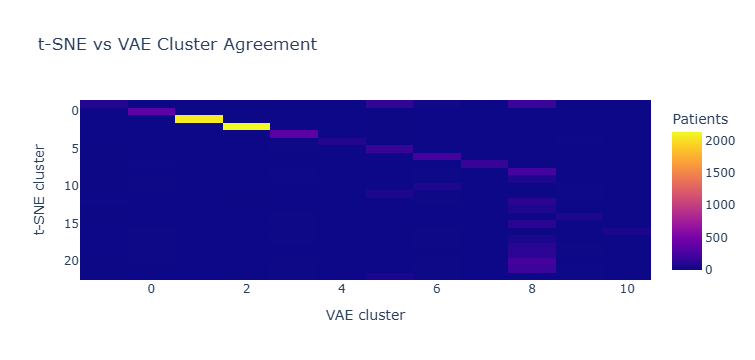

In [29]:
fig = px.imshow(
    tsne_vae_table,
    labels=dict(x="VAE cluster", y="t-SNE cluster", color="Patients"),
    title="t-SNE vs VAE Cluster Agreement",
    aspect="auto"
)

fig.write_html(
    PLOTS_DIR / "tsne_vae_contingency.html"
)

print("Saved:", PLOTS_DIR / "tsne_vae_contingency.html")

fig.show()

## UMAP vs VAE heatmap

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\umap_vae_contingency.html


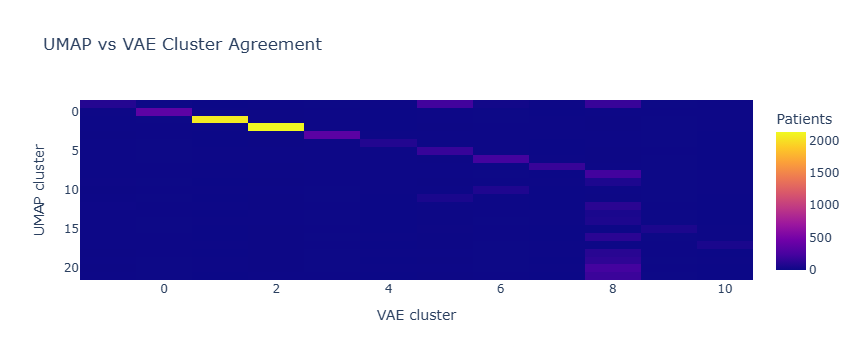

In [30]:
fig = px.imshow(
    umap_vae_table,
    labels=dict(x="VAE cluster", y="UMAP cluster", color="Patients"),
    title="UMAP vs VAE Cluster Agreement",
    aspect="auto"
)

fig.write_html(
    PLOTS_DIR / "umap_vae_contingency.html"
)

print("Saved:", PLOTS_DIR / "umap_vae_contingency.html")

fig.show()

## Check dataset preparation files

In [31]:
DATASET_DIR = PROJECT_ROOT / "results" / "module_2" / "dataset_creation"

print("Dataset preparation files:")
for file in DATASET_DIR.iterdir():
    print(file.name)

Dataset preparation files:
.ipynb_checkpoints
clustering_feature_names.csv
feature_data_complete.csv
feature_data_encoded.csv
feature_data_scaled.csv
hr_eigenvalues.npy
hr_fpc_scores.csv
rr_eigenvalues.npy
rr_fpc_scores.csv
sao2_eigenvalues.npy
sao2_fpc_scores.csv
vital_fpc_features.csv


## Load the Scaled Feature Dataset

In [32]:
feature_data_scaled = pd.read_csv(
    DATASET_DIR / "feature_data_scaled.csv"
)

print("Shape:", feature_data_scaled.shape)
print("First 10 columns:", feature_data_scaled.columns[:10].tolist())
print("Last 5 columns:", feature_data_scaled.columns[-5:].tolist())

Shape: (7648, 81)
First 10 columns: ['patientunitstayid', 'age', 'gender', 'admissionheight', 'admissionweight', 'min_BUN', 'min_Hgb', 'min_WBC x 1000', 'min_anion gap', 'min_bicarbonate']
Last 5 columns: ['unittype_Cardiac ICU', 'unittype_MICU', 'unittype_Med-Surg ICU', 'unittype_Neuro ICU', 'unittype_SICU']


## Prepare SOM feature matrix

In [33]:
patient_ids = feature_data_scaled["patientunitstayid"].copy()

X_som = feature_data_scaled.drop(
    columns=["patientunitstayid"]
).copy()

print("SOM feature matrix shape:", X_som.shape)
print("Missing values:", X_som.isna().sum().sum())
print("Minimum value:", X_som.min().min())
print("Maximum value:", X_som.max().max())

SOM feature matrix shape: (7648, 80)
Missing values: 0
Minimum value: 0.0
Maximum value: 1.0000000000000002


## Define SOM settings

In [34]:
SOM_ROWS = 35
SOM_COLS = 35

sigma_values = np.arange(1, 11)

X_som_array = X_som.to_numpy()

print("SOM grid:", SOM_ROWS, "x", SOM_COLS)
print("Number of neurons:", SOM_ROWS * SOM_COLS)
print("Sigma values:", sigma_values)
print("Input shape:", X_som_array.shape)

SOM grid: 35 x 35
Number of neurons: 1225
Sigma values: [ 1  2  3  4  5  6  7  8  9 10]
Input shape: (7648, 80)


## SOM tuning settings

In [35]:
SOM_LEARNING_RATE = 0.5
SOM_TUNING_ITERATIONS = 1000
SOM_RANDOM_SEED = 42

print("Learning rate:", SOM_LEARNING_RATE)
print("Tuning iterations:", SOM_TUNING_ITERATIONS)
print("Random seed:", SOM_RANDOM_SEED)

Learning rate: 0.5
Tuning iterations: 1000
Random seed: 42


## Define SOM evaluation function

In [36]:
def evaluate_som_sigma(sigma):
    som = MiniSom(
        SOM_ROWS,
        SOM_COLS,
        X_som_array.shape[1],
        sigma=sigma,
        learning_rate=SOM_LEARNING_RATE,
        random_seed=SOM_RANDOM_SEED
    )

    som.random_weights_init(X_som_array)

    som.train_random(
        X_som_array,
        SOM_TUNING_ITERATIONS
    )

    qe = som.quantization_error(X_som_array)
    te = som.topographic_error(X_som_array)

    return qe, te

## Test sigma = 1

In [37]:
qe_1, te_1 = evaluate_som_sigma(1)

print("Sigma = 1")
print("Quantization Error:", round(qe_1, 4))
print("Topographic Error:", round(te_1, 4))

Sigma = 1
Quantization Error: 0.5118
Topographic Error: 0.9608


## Evaluate all sigma values

In [38]:
som_tuning_results = []

for sigma in sigma_values:
    qe, te = evaluate_som_sigma(sigma)

    som_tuning_results.append({
        "sigma": sigma,
        "quantization_error": qe,
        "topographic_error": te
    })

    print(
        f"Sigma {sigma}: "
        f"QE = {qe:.4f}, TE = {te:.4f}"
    )

Sigma 1: QE = 0.5118, TE = 0.9608
Sigma 2: QE = 0.5869, TE = 0.2930
Sigma 3: QE = 0.6020, TE = 0.0666
Sigma 4: QE = 0.6295, TE = 0.0429
Sigma 5: QE = 0.6494, TE = 0.0265
Sigma 6: QE = 0.6747, TE = 0.0263
Sigma 7: QE = 0.6930, TE = 0.0216
Sigma 8: QE = 0.7054, TE = 0.0132
Sigma 9: QE = 0.7207, TE = 0.0129
Sigma 10: QE = 0.7388, TE = 0.0112


## Compare QE and TE on the same scale

In [39]:
# Convert tuning results to a DataFrame

som_tuning_df = pd.DataFrame(som_tuning_results)

# Normalize both errors to a 0-1 scale
som_tuning_df["qe_normalized"] = (
    som_tuning_df["quantization_error"]
    - som_tuning_df["quantization_error"].min()
) / (
    som_tuning_df["quantization_error"].max()
    - som_tuning_df["quantization_error"].min()
)

som_tuning_df["te_normalized"] = (
    som_tuning_df["topographic_error"]
    - som_tuning_df["topographic_error"].min()
) / (
    som_tuning_df["topographic_error"].max()
    - som_tuning_df["topographic_error"].min()
)

# Simple joint trade-off score
som_tuning_df["combined_score"] = (
    som_tuning_df["qe_normalized"]
    + som_tuning_df["te_normalized"]
)

display(som_tuning_df.round(4))

,sigma,quantization_error,topographic_error,qe_normalized,te_normalized,combined_score
0,1,0.5118,0.9608,0.0000,1.0000,1.0000
1,2,0.5869,0.2930,0.3307,0.2968,0.6275
2,3,0.6020,0.0666,0.3972,0.0582,0.4554
3,4,0.6295,0.0429,0.5186,0.0333,0.5519
4,5,0.6494,0.0265,0.6062,0.0161,0.6223
5,6,0.6747,0.0263,0.7178,0.0158,0.7336
6,7,0.6930,0.0216,0.7984,0.0109,0.8092
7,8,0.7054,0.0132,0.8527,0.0021,0.8548
8,9,0.7207,0.0129,0.9202,0.0018,0.9220
9,10,0.7388,0.0112,1.0000,0.0000,1.0000


## Select the final sigma

In [40]:
best_row = som_tuning_df.loc[
    som_tuning_df["combined_score"].idxmin()
]

BEST_SIGMA = int(best_row["sigma"])

print("Selected sigma:", BEST_SIGMA)
print("Quantization Error:", round(best_row["quantization_error"], 4))
print("Topographic Error:", round(best_row["topographic_error"], 4))

Selected sigma: 3
Quantization Error: 0.602
Topographic Error: 0.0666


## Train the final SOM

In [41]:
final_som = MiniSom(
    SOM_ROWS,
    SOM_COLS,
    X_som_array.shape[1],
    sigma=BEST_SIGMA,
    learning_rate=SOM_LEARNING_RATE,
    random_seed=SOM_RANDOM_SEED
)

final_som.random_weights_init(X_som_array)

final_som.train_random(
    X_som_array,
    SOM_TUNING_ITERATIONS
)

print("Final SOM training completed.")

Final SOM training completed.


## Compute the U-Matrix

In [42]:
u_matrix = final_som.distance_map()

print("U-Matrix shape:", u_matrix.shape)
print("Minimum distance:", round(u_matrix.min(), 4))
print("Maximum distance:", round(u_matrix.max(), 4))

U-Matrix shape: (35, 35)
Minimum distance: 0.0617
Maximum distance: 1.0


## Plot the SOM U-Matrix

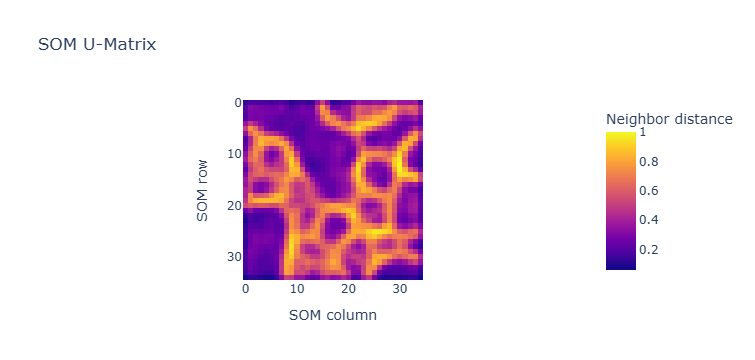

In [43]:
fig = px.imshow(
    u_matrix,
    labels=dict(
        x="SOM column",
        y="SOM row",
        color="Neighbor distance"
    ),
    title="SOM U-Matrix",
    aspect="equal"
)

fig.show()

## Find each patient BMU

In [44]:
bmu_coordinates = np.array([
    final_som.winner(row)
    for row in X_som_array
])

print("BMU coordinate shape:", bmu_coordinates.shape)
print("First 5 BMU coordinates:")
print(bmu_coordinates[:5])

BMU coordinate shape: (7648, 2)
First 5 BMU coordinates:
[[12 34]
 [32 10]
 [ 1  5]
 [12 18]
 [34  0]]


## Create patient-to-SOM mapping

In [45]:
som_patient_map = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "som_row": bmu_coordinates[:, 0],
    "som_col": bmu_coordinates[:, 1]
})

print("SOM patient map shape:", som_patient_map.shape)
display(som_patient_map.head())

SOM patient map shape: (7648, 3)


,patientunitstayid,som_row,som_col
0,151900,12,34
1,210208,32,10
2,179269,1,5
3,172764,12,18
4,166175,34,0


## Attach t-SNE cluster labels to SOM coordinates

In [46]:
tsne_som_projection = som_patient_map.merge(
    tsne_clusters[["patientunitstayid", "cluster"]],
    on="patientunitstayid",
    how="inner"
)

print("t-SNE SOM projection shape:", tsne_som_projection.shape)
display(tsne_som_projection.head())

t-SNE SOM projection shape: (7648, 4)


,patientunitstayid,som_row,som_col,cluster
0,151900,12,34,0
1,210208,32,10,-1
2,179269,1,5,1
3,172764,12,18,1
4,166175,34,0,2


## Project t-SNE clusters onto the SOM U-Matrix

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\tsne_som_projection.html


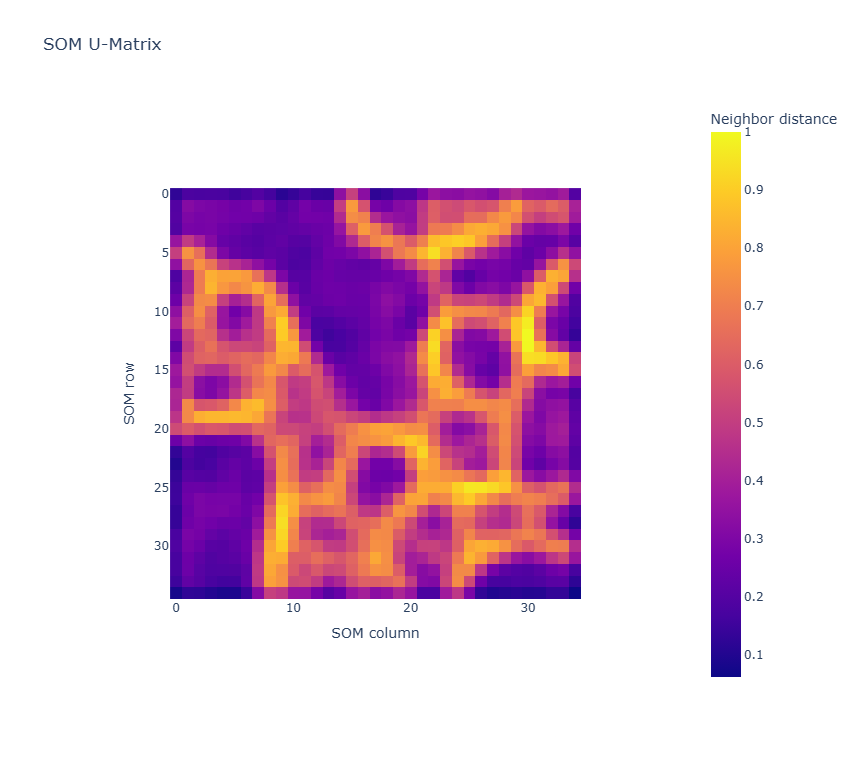

In [47]:
fig.update_traces(
    marker=dict(size=3),
    opacity=0.55,
    selector=dict(type="scatter")
)

fig.update_layout(
    width=1100,
    height=750,
    legend=dict(
        title="t-SNE Cluster",
        x=1.18,
        y=1,
        font=dict(size=9)
    )
)

fig.update_coloraxes(
    colorbar=dict(
        title="Neighbor distance",
        x=1.05
    )
)

fig.write_html(
    PLOTS_DIR / "tsne_som_projection.html"
)

print("Saved:", PLOTS_DIR / "tsne_som_projection.html")

fig.show()

## UMAP SOM projection + save

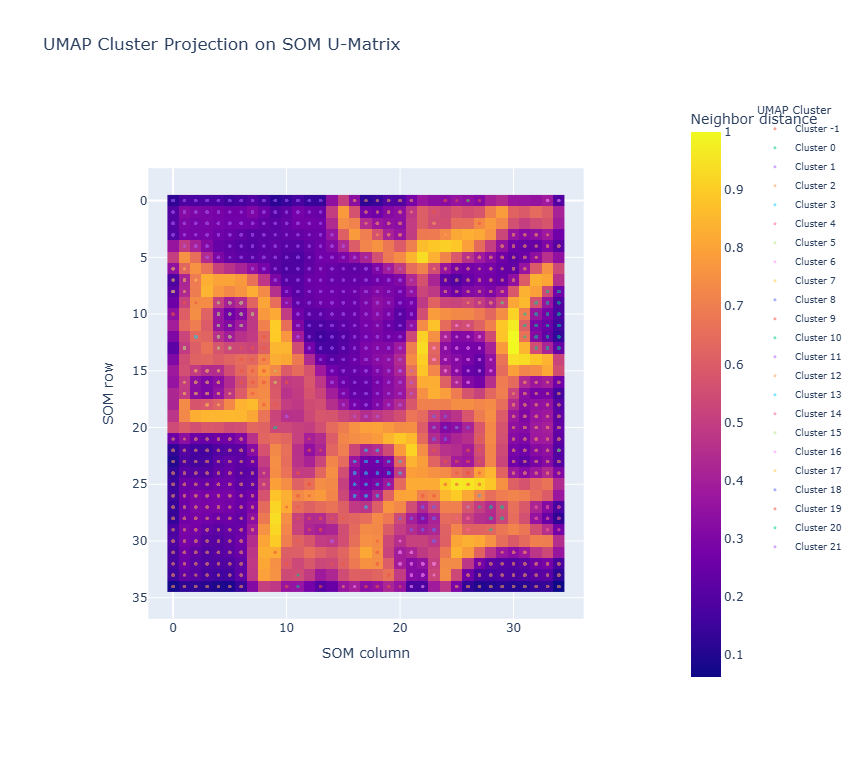

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\umap_som_projection.html


In [48]:
# Merge UMAP cluster labels with SOM coordinates

umap_som_projection = som_patient_map.merge(
    umap_clusters[["patientunitstayid", "cluster"]],
    on="patientunitstayid",
    how="inner"
)

# Plot UMAP clusters on the SOM U-Matrix

fig = px.imshow(
    u_matrix,
    labels=dict(
        x="SOM column",
        y="SOM row",
        color="Neighbor distance"
    ),
    title="UMAP Cluster Projection on SOM U-Matrix",
    aspect="equal"
)

for cluster_id in sorted(umap_som_projection["cluster"].unique()):
    subset = umap_som_projection[
        umap_som_projection["cluster"] == cluster_id
    ]

    fig.add_trace(
        go.Scatter(
            x=subset["som_col"],
            y=subset["som_row"],
            mode="markers",
            name=f"Cluster {cluster_id}",
            marker=dict(size=3),
            opacity=0.55
        )
    )

fig.update_layout(
    width=1100,
    height=750,
    legend=dict(
        title="UMAP Cluster",
        x=1.18,
        y=1,
        font=dict(size=9)
    )
)

fig.update_coloraxes(
    colorbar=dict(
        title="Neighbor distance",
        x=1.05
    )
)

fig.show()

# Save interactive plot

fig.write_html(
    PLOTS_DIR / "umap_som_projection.html"
)

print("Saved:", PLOTS_DIR / "umap_som_projection.html")

## VAE SOM projection + save

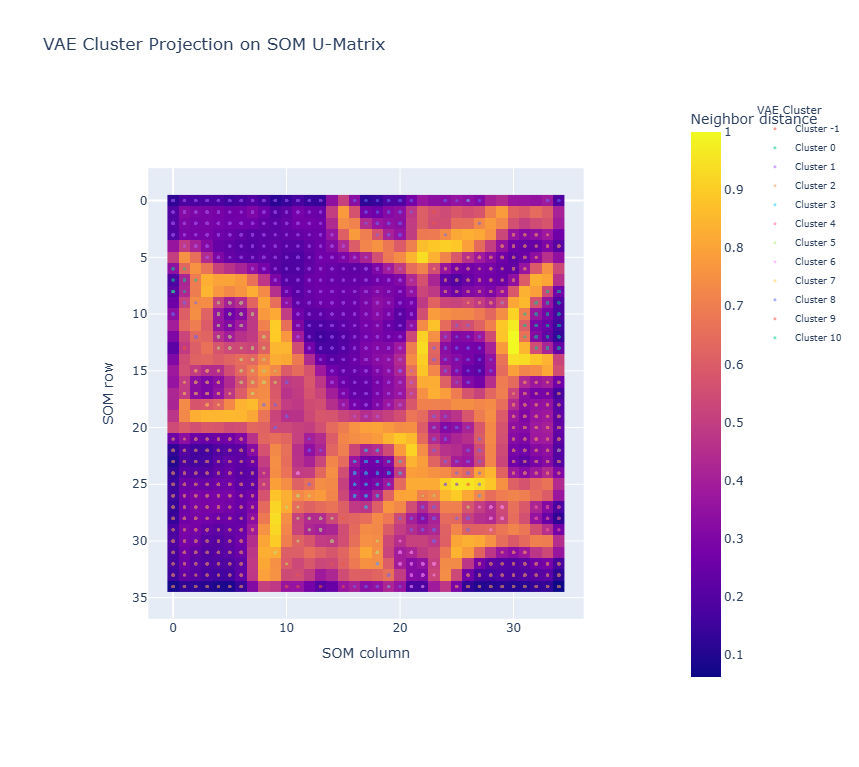

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\vae_som_projection.html


In [49]:
# Merge VAE cluster labels with SOM coordinates

vae_som_projection = som_patient_map.merge(
    vae_clusters[["patientunitstayid", "cluster"]],
    on="patientunitstayid",
    how="inner"
)

# Plot VAE clusters on the SOM U-Matrix

fig = px.imshow(
    u_matrix,
    labels=dict(
        x="SOM column",
        y="SOM row",
        color="Neighbor distance"
    ),
    title="VAE Cluster Projection on SOM U-Matrix",
    aspect="equal"
)

for cluster_id in sorted(vae_som_projection["cluster"].unique()):
    subset = vae_som_projection[
        vae_som_projection["cluster"] == cluster_id
    ]

    fig.add_trace(
        go.Scatter(
            x=subset["som_col"],
            y=subset["som_row"],
            mode="markers",
            name=f"Cluster {cluster_id}",
            marker=dict(size=3),
            opacity=0.55
        )
    )

fig.update_layout(
    width=1100,
    height=750,
    legend=dict(
        title="VAE Cluster",
        x=1.18,
        y=1,
        font=dict(size=9)
    )
)

fig.update_coloraxes(
    colorbar=dict(
        title="Neighbor distance",
        x=1.05
    )
)

fig.show()

# Save interactive plot

fig.write_html(
    PLOTS_DIR / "vae_som_projection.html"
)

print("Saved:", PLOTS_DIR / "vae_som_projection.html")

## Inspect available patient variables

In [50]:
feature_data_complete = pd.read_csv(
    DATASET_DIR / "feature_data_complete.csv"
)

print("Shape:", feature_data_complete.shape)

print("\nAvailable columns:")
print(feature_data_complete.columns.tolist())

Shape: (7648, 70)

Available columns:
['patientunitstayid', 'age', 'gender', 'ethnicity', 'admissionheight', 'unittype', 'admissionweight', 'min_BUN', 'min_Hgb', 'min_WBC x 1000', 'min_anion gap', 'min_bicarbonate', 'min_chloride', 'min_creatinine', 'min_glucose', 'min_lactate', 'min_platelets x 1000', 'min_potassium', 'min_sodium', 'max_BUN', 'max_Hgb', 'max_WBC x 1000', 'max_anion gap', 'max_bicarbonate', 'max_chloride', 'max_creatinine', 'max_glucose', 'max_lactate', 'max_platelets x 1000', 'max_potassium', 'max_sodium', 'mean_BUN', 'mean_Hgb', 'mean_WBC x 1000', 'mean_anion gap', 'mean_bicarbonate', 'mean_chloride', 'mean_creatinine', 'mean_glucose', 'mean_lactate', 'mean_platelets x 1000', 'mean_potassium', 'mean_sodium', 'std_BUN', 'std_Hgb', 'std_WBC x 1000', 'std_anion gap', 'std_bicarbonate', 'std_chloride', 'std_creatinine', 'std_glucose', 'std_lactate', 'std_platelets x 1000', 'std_potassium', 'std_sodium', 'total_lab_measurements', 'sao2_fpc1', 'sao2_fpc2', 'sao2_fpc3', 'sa

## Inspect the patient table

In [51]:
patient = pd.read_csv(
    PROJECT_ROOT / "data" / "patient.csv"
)

print("Patient table shape:", patient.shape)

outcome_columns = [
    col for col in patient.columns
    if any(word in col.lower() for word in [
        "discharge", "mortality", "status"
    ])
]

print("\nPotential outcome columns:")
print(outcome_columns)

Patient table shape: (200859, 29)

Potential outcome columns:
['hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'dischargeweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus']


## Inspect mortality status values and LOS offsets

In [52]:
print("Hospital discharge status:")
print(patient["hospitaldischargestatus"].value_counts(dropna=False))

print("\nICU discharge status:")
print(patient["unitdischargestatus"].value_counts(dropna=False))

print("\nHospital discharge offset summary:")
print(patient["hospitaldischargeoffset"].describe())

print("\nICU discharge offset summary:")
print(patient["unitdischargeoffset"].describe())

Hospital discharge status:
hospitaldischargestatus
Alive      181104
Expired     18004
NaN          1751
Name: count, dtype: int64

ICU discharge status:
unitdischargestatus
Alive      189918
Expired     10907
NaN            34
Name: count, dtype: int64

Hospital discharge offset summary:
count    2.008590e+05
mean     9.763672e+03
std      1.493003e+04
min     -8.549000e+03
25%      3.322000e+03
50%      6.545000e+03
75%      1.155800e+04
max      1.579315e+06
Name: hospitaldischargeoffset, dtype: float64

ICU discharge offset summary:
count    200859.000000
mean       3858.131913
std        6236.445188
min       -7687.000000
25%        1179.000000
50%        2266.000000
75%        4279.000000
max      729176.000000
Name: unitdischargeoffset, dtype: float64


## Inspect outcomes within our cohort

In [53]:
cohort_outcomes_raw = feature_data_complete[["patientunitstayid"]].merge(
    patient[
        [
            "patientunitstayid",
            "unitdischargestatus",
            "hospitaldischargestatus",
            "unitdischargeoffset",
            "hospitaldischargeoffset"
        ]
    ],
    on="patientunitstayid",
    how="left"
)

print("Cohort outcome shape:", cohort_outcomes_raw.shape)

print("\nMissing values:")
print(cohort_outcomes_raw.isna().sum())

print("\nNegative ICU discharge offsets:",
      (cohort_outcomes_raw["unitdischargeoffset"] < 0).sum())

print("Negative hospital discharge offsets:",
      (cohort_outcomes_raw["hospitaldischargeoffset"] < 0).sum())

Cohort outcome shape: (7648, 5)

Missing values:
patientunitstayid           0
unitdischargestatus         0
hospitaldischargestatus    73
unitdischargeoffset         0
hospitaldischargeoffset     0
dtype: int64

Negative ICU discharge offsets: 0
Negative hospital discharge offsets: 1


## Create mortality and LOS outcomes

In [54]:
# Create mortality and length-of-stay outcome variables

cohort_outcomes = cohort_outcomes_raw.copy()

# Mortality: 1 = Expired, 0 = Alive
cohort_outcomes["icu_mortality"] = (
    cohort_outcomes["unitdischargestatus"]
    .map({"Alive": 0, "Expired": 1})
)

cohort_outcomes["hospital_mortality"] = (
    cohort_outcomes["hospitaldischargestatus"]
    .map({"Alive": 0, "Expired": 1})
)

# Convert discharge offsets from minutes to days
cohort_outcomes["icu_los_days"] = (
    cohort_outcomes["unitdischargeoffset"] / 1440
)

cohort_outcomes["hospital_los_days"] = (
    cohort_outcomes["hospitaldischargeoffset"] / 1440
)

# Treat impossible negative hospital LOS as missing
cohort_outcomes.loc[
    cohort_outcomes["hospital_los_days"] < 0,
    "hospital_los_days"
] = np.nan

print(
    cohort_outcomes[
        [
            "icu_mortality",
            "hospital_mortality",
            "icu_los_days",
            "hospital_los_days"
        ]
    ].describe()
)

       icu_mortality  hospital_mortality  icu_los_days  hospital_los_days
count    7648.000000         7575.000000   7648.000000        7647.000000
mean        0.129184            0.195512      4.098778           9.223338
std         0.335426            0.396620      5.644635           9.744564
min         0.000000            0.000000      0.000000           0.077083
25%         0.000000            0.000000      1.375694           3.793750
50%         0.000000            0.000000      2.474653           6.743750
75%         0.000000            0.000000      4.780729          11.506250
max         1.000000            1.000000    246.904167         246.904167


## Inspect APACHE table columns

In [55]:
apache = pd.read_csv(
    PROJECT_ROOT / "data" / "apachePatientResult.csv"
)

print("APACHE table shape:", apache.shape)

print("\nAPACHE / score-related columns:")
print([
    col for col in apache.columns
    if "apache" in col.lower() or "score" in col.lower()
])

APACHE table shape: (297064, 23)

APACHE / score-related columns:
['apachepatientresultsid', 'acutephysiologyscore', 'apachescore', 'apacheversion']


## Check APACHE versions

In [56]:
print(apache["apacheversion"].value_counts(dropna=False))

apacheversion
IV     148532
IVa    148532
Name: count, dtype: int64


## Prepare APACHE IVa scores


In [57]:
apache_iva = apache[
    apache["apacheversion"] == "IVa"
][["patientunitstayid", "apachescore"]].copy()

print("APACHE IVa rows:", len(apache_iva))
print("Unique ICU stays:", apache_iva["patientunitstayid"].nunique())
print("Duplicate ICU stays:", apache_iva["patientunitstayid"].duplicated().sum())
print("Missing APACHE scores:", apache_iva["apachescore"].isna().sum())

APACHE IVa rows: 148532
Unique ICU stays: 148532
Duplicate ICU stays: 0
Missing APACHE scores: 0


## Merge APACHE IVa into outcomes

In [58]:
cohort_outcomes = cohort_outcomes.merge(
    apache_iva,
    on="patientunitstayid",
    how="left"
)

print("Evaluation outcome shape:", cohort_outcomes.shape)
print("Missing APACHE IVa scores:", cohort_outcomes["apachescore"].isna().sum())

print("\nAPACHE IVa summary:")
print(cohort_outcomes["apachescore"].describe())

Evaluation outcome shape: (7648, 10)
Missing APACHE IVa scores: 934

APACHE IVa summary:
count    6714.000000
mean       73.665624
std        27.779184
min        -1.000000
25%        54.000000
50%        70.000000
75%        89.000000
max       195.000000
Name: apachescore, dtype: float64


## Check invalid APACHE scores

In [59]:
print("APACHE score = -1:",
      (cohort_outcomes["apachescore"] == -1).sum())

print("APACHE score < 0:",
      (cohort_outcomes["apachescore"] < 0).sum())

APACHE score = -1: 19
APACHE score < 0: 19


## Clean APACHE IVa values

In [60]:
cohort_outcomes.loc[
    cohort_outcomes["apachescore"] < 0,
    "apachescore"
] = np.nan

print("Missing APACHE IVa scores after cleaning:",
      cohort_outcomes["apachescore"].isna().sum())

Missing APACHE IVa scores after cleaning: 953


## Create t-SNE cluster outcome table

In [61]:
tsne_cluster_outcomes = (
    tsne_clusters[["patientunitstayid", "cluster"]]
    .merge(
        feature_data_complete[["patientunitstayid", "age"]],
        on="patientunitstayid",
        how="left"
    )
    .merge(
        cohort_outcomes[
            [
                "patientunitstayid",
                "apachescore",
                "icu_los_days",
                "hospital_los_days",
                "icu_mortality",
                "hospital_mortality"
            ]
        ],
        on="patientunitstayid",
        how="left"
    )
)

print("t-SNE outcome dataset shape:", tsne_cluster_outcomes.shape)
display(tsne_cluster_outcomes.head())

t-SNE outcome dataset shape: (7648, 8)


,patientunitstayid,cluster,age,apachescore,icu_los_days,hospital_los_days,icu_mortality,hospital_mortality
0,151900,0,66.0,68.0,2.402778,4.413194,0,0.0
1,210208,-1,52.0,49.0,3.804167,5.800000,0,0.0
2,179269,1,82.0,117.0,2.538194,16.727083,0,0.0
3,172764,1,71.0,NaN,1.442361,7.620833,0,0.0
4,166175,2,60.0,47.0,0.815972,6.970139,0,0.0


## t-SNE cluster outcome summary

In [62]:
tsne_outcome_summary = (
    tsne_cluster_outcomes[
        tsne_cluster_outcomes["cluster"] != -1
    ]
    .groupby("cluster")
    .agg(
        cluster_size=("patientunitstayid", "size"),
        age_mean=("age", "mean"),
        apache_score_mean=("apachescore", "mean"),
        icu_los_days_mean=("icu_los_days", "mean"),
        hospital_los_days_mean=("hospital_los_days", "mean"),
        icu_mortality_pct=("icu_mortality", "mean"),
        hospital_mortality_pct=("hospital_mortality", "mean")
    )
    .reset_index()
)

tsne_outcome_summary["icu_mortality_pct"] *= 100
tsne_outcome_summary["hospital_mortality_pct"] *= 100

display(tsne_outcome_summary.round(2))

,cluster,cluster_size,age_mean,apache_score_mean,icu_los_days_mean,hospital_los_days_mean,icu_mortality_pct,hospital_mortality_pct
0,0,363,67.09,75.78,3.94,9.17,14.33,19.67
1,1,2060,66.49,73.34,3.68,8.34,13.01,19.26
2,2,2128,66.33,73.73,3.99,8.71,12.55,18.90
3,3,347,67.34,76.10,4.20,10.57,15.27,20.00
4,4,87,64.51,73.37,4.65,10.92,14.94,19.54
5,5,173,61.27,80.33,3.95,9.83,12.14,21.43
6,6,227,67.21,73.58,4.13,8.67,10.57,21.15
7,7,170,59.53,72.25,4.29,10.47,10.00,19.41
8,8,223,66.32,72.37,3.95,8.67,11.21,17.94
9,9,65,65.22,75.70,9.08,13.86,18.46,19.05


## Save t-SNE outcome summary

In [63]:
tsne_outcome_summary.to_csv(
    EVALUATION_DIR / "tsne_cluster_outcomes.csv",
    index=False
)

print("Saved:", EVALUATION_DIR / "tsne_cluster_outcomes.csv")

Saved: C:\Users\samsa\Documents\ICU Clustering\results\module_2\evaluation\tsne_cluster_outcomes.csv


## UMAP cluster outcome table + save

In [64]:
# Create UMAP patient-level outcome dataset

umap_cluster_outcomes = (
    umap_clusters[["patientunitstayid", "cluster"]]
    .merge(
        feature_data_complete[["patientunitstayid", "age"]],
        on="patientunitstayid",
        how="left"
    )
    .merge(
        cohort_outcomes[
            [
                "patientunitstayid",
                "apachescore",
                "icu_los_days",
                "hospital_los_days",
                "icu_mortality",
                "hospital_mortality"
            ]
        ],
        on="patientunitstayid",
        how="left"
    )
)

# Aggregate to cluster level

umap_outcome_summary = (
    umap_cluster_outcomes[
        umap_cluster_outcomes["cluster"] != -1
    ]
    .groupby("cluster")
    .agg(
        cluster_size=("patientunitstayid", "size"),
        age_mean=("age", "mean"),
        apache_score_mean=("apachescore", "mean"),
        icu_los_days_mean=("icu_los_days", "mean"),
        hospital_los_days_mean=("hospital_los_days", "mean"),
        icu_mortality_pct=("icu_mortality", "mean"),
        hospital_mortality_pct=("hospital_mortality", "mean")
    )
    .reset_index()
)

umap_outcome_summary["icu_mortality_pct"] *= 100
umap_outcome_summary["hospital_mortality_pct"] *= 100

display(umap_outcome_summary.round(2))

# Save result

umap_outcome_summary.to_csv(
    EVALUATION_DIR / "umap_cluster_outcomes.csv",
    index=False
)

print("Saved:", EVALUATION_DIR / "umap_cluster_outcomes.csv")

,cluster,cluster_size,age_mean,apache_score_mean,icu_los_days_mean,hospital_los_days_mean,icu_mortality_pct,hospital_mortality_pct
0,0,363,67.09,75.78,3.94,9.17,14.33,19.67
1,1,2060,66.49,73.34,3.68,8.34,13.01,19.26
2,2,2128,66.33,73.73,3.99,8.71,12.55,18.90
3,3,345,67.41,76.00,4.18,10.59,15.07,19.53
4,4,87,64.51,73.37,4.65,10.92,14.94,19.54
5,5,173,61.27,80.33,3.95,9.83,12.14,21.43
6,6,227,67.21,73.58,4.13,8.67,10.57,21.15
7,7,170,59.53,72.25,4.29,10.47,10.00,19.41
8,8,223,66.32,72.37,3.95,8.67,11.21,17.94
9,9,69,64.58,77.88,8.77,13.93,17.39,19.40


Saved: C:\Users\samsa\Documents\ICU Clustering\results\module_2\evaluation\umap_cluster_outcomes.csv


## VAE cluster outcome table + save

In [65]:
# Create VAE patient-level outcome dataset

vae_cluster_outcomes = (
    vae_clusters[["patientunitstayid", "cluster"]]
    .merge(
        feature_data_complete[["patientunitstayid", "age"]],
        on="patientunitstayid",
        how="left"
    )
    .merge(
        cohort_outcomes[
            [
                "patientunitstayid",
                "apachescore",
                "icu_los_days",
                "hospital_los_days",
                "icu_mortality",
                "hospital_mortality"
            ]
        ],
        on="patientunitstayid",
        how="left"
    )
)

# Aggregate to cluster level

vae_outcome_summary = (
    vae_cluster_outcomes[
        vae_cluster_outcomes["cluster"] != -1
    ]
    .groupby("cluster")
    .agg(
        cluster_size=("patientunitstayid", "size"),
        age_mean=("age", "mean"),
        apache_score_mean=("apachescore", "mean"),
        icu_los_days_mean=("icu_los_days", "mean"),
        hospital_los_days_mean=("hospital_los_days", "mean"),
        icu_mortality_pct=("icu_mortality", "mean"),
        hospital_mortality_pct=("hospital_mortality", "mean")
    )
    .reset_index()
)

vae_outcome_summary["icu_mortality_pct"] *= 100
vae_outcome_summary["hospital_mortality_pct"] *= 100

display(vae_outcome_summary.round(2))

# Save result

vae_outcome_summary.to_csv(
    EVALUATION_DIR / "vae_cluster_outcomes.csv",
    index=False
)

print("Saved:", EVALUATION_DIR / "vae_cluster_outcomes.csv")

,cluster,cluster_size,age_mean,apache_score_mean,icu_los_days_mean,hospital_los_days_mean,icu_mortality_pct,hospital_mortality_pct
0,0,360,67.24,75.77,3.95,9.16,14.44,19.83
1,1,2060,66.49,73.34,3.68,8.34,13.01,19.26
2,2,2128,66.33,73.73,3.99,8.71,12.55,18.90
3,3,345,67.41,76.00,4.18,10.59,15.07,19.53
4,4,87,64.51,73.37,4.65,10.92,14.94,19.54
5,5,454,60.11,77.43,4.60,11.28,15.64,23.21
6,6,321,66.37,73.25,4.26,9.63,9.35,18.69
7,7,170,59.53,72.25,4.29,10.47,10.00,19.41
8,8,1496,64.16,73.17,4.62,9.93,12.30,19.57
9,9,61,64.23,68.19,3.98,7.72,18.03,21.31


Saved: C:\Users\samsa\Documents\ICU Clustering\results\module_2\evaluation\vae_cluster_outcomes.csv


## t-SNE clinical feature profiles + save

In [66]:
# Create t-SNE cluster clinical feature profiles

tsne_feature_profiles = (
    tsne_clusters[["patientunitstayid", "cluster"]]
    .merge(
        feature_data_complete,
        on="patientunitstayid",
        how="left"
    )
)

# Keep regular clusters only
tsne_feature_profiles = tsne_feature_profiles[
    tsne_feature_profiles["cluster"] != -1
]

# Numeric clinical variables only
numeric_features = (
    tsne_feature_profiles
    .select_dtypes(include=np.number)
    .columns
    .difference(["patientunitstayid", "cluster"])
)

tsne_cluster_profiles = (
    tsne_feature_profiles
    .groupby("cluster")[numeric_features]
    .mean()
    .reset_index()
)

display(tsne_cluster_profiles.head())

# Save result
tsne_cluster_profiles.to_csv(
    EVALUATION_DIR / "tsne_cluster_profiles.csv",
    index=False
)

print("Saved:", EVALUATION_DIR / "tsne_cluster_profiles.csv")

,cluster,admissionheight,admissionweight,age,hr_fpc1,hr_fpc2,max_BUN,max_Hgb,max_WBC x 1000,max_anion gap,...,std_anion gap,std_bicarbonate,std_chloride,std_creatinine,std_glucose,std_lactate,std_platelets x 1000,std_potassium,std_sodium,total_lab_measurements
0,0,161.713774,80.010468,67.090909,16.543765,-19.251182,35.418733,10.382645,17.456501,13.275482,...,1.081919,1.028891,1.034988,0.116015,21.718008,0.550527,8.315883,0.248796,1.183221,68.834711
1,1,161.243267,77.227728,66.492718,2.773517,-17.933662,32.958350,10.404369,16.579782,13.417961,...,0.867378,0.903477,1.118143,0.105747,18.299499,0.464302,7.383926,0.219136,0.960772,65.362136
2,2,176.097829,89.853722,66.331767,67.392854,-26.197480,37.675940,10.975282,16.257411,13.096053,...,0.942500,0.932242,1.047881,0.127797,17.865486,0.469890,6.997458,0.203004,0.950762,65.648496
3,3,176.060980,92.252968,67.340058,64.577227,-44.130026,39.974063,10.938617,16.810317,12.622478,...,1.018221,0.995023,1.039767,0.135884,17.233176,0.423091,8.207500,0.216444,0.997522,64.440922
4,4,177.673563,94.552874,64.505747,-16.487674,-32.420883,35.977011,10.459770,15.623103,12.413793,...,0.991941,0.825704,0.975826,0.107033,12.428380,0.308539,7.835953,0.216842,0.910742,63.931034


Saved: C:\Users\samsa\Documents\ICU Clustering\results\module_2\evaluation\tsne_cluster_profiles.csv


## UMAP clinical feature profiles + save

In [67]:
# Create UMAP cluster clinical feature profiles

umap_feature_profiles = (
    umap_clusters[["patientunitstayid", "cluster"]]
    .merge(
        feature_data_complete,
        on="patientunitstayid",
        how="left"
    )
)

umap_feature_profiles = umap_feature_profiles[
    umap_feature_profiles["cluster"] != -1
]

umap_cluster_profiles = (
    umap_feature_profiles
    .groupby("cluster")[numeric_features]
    .mean()
    .reset_index()
)

display(umap_cluster_profiles.head())

umap_cluster_profiles.to_csv(
    EVALUATION_DIR / "umap_cluster_profiles.csv",
    index=False
)

print("Saved:", EVALUATION_DIR / "umap_cluster_profiles.csv")

,cluster,admissionheight,admissionweight,age,hr_fpc1,hr_fpc2,max_BUN,max_Hgb,max_WBC x 1000,max_anion gap,...,std_anion gap,std_bicarbonate,std_chloride,std_creatinine,std_glucose,std_lactate,std_platelets x 1000,std_potassium,std_sodium,total_lab_measurements
0,0,161.713774,80.010468,67.090909,16.543765,-19.251182,35.418733,10.382645,17.456501,13.275482,...,1.081919,1.028891,1.034988,0.116015,21.718008,0.550527,8.315883,0.248796,1.183221,68.834711
1,1,161.243267,77.227728,66.492718,2.773517,-17.933662,32.958350,10.404369,16.579782,13.417961,...,0.867378,0.903477,1.118143,0.105747,18.299499,0.464302,7.383926,0.219136,0.960772,65.362136
2,2,176.097829,89.853722,66.331767,67.392854,-26.197480,37.675940,10.975282,16.257411,13.096053,...,0.942500,0.932242,1.047881,0.127797,17.865486,0.469890,6.997458,0.203004,0.950762,65.648496
3,3,176.043652,91.952986,67.414493,68.518950,-44.007671,39.971014,10.954783,16.724290,12.611594,...,1.013662,0.991859,1.036346,0.135640,17.164820,0.424760,8.046994,0.213189,0.988243,63.910145
4,4,177.673563,94.552874,64.505747,-16.487674,-32.420883,35.977011,10.459770,15.623103,12.413793,...,0.991941,0.825704,0.975826,0.107033,12.428380,0.308539,7.835953,0.216842,0.910742,63.931034


Saved: C:\Users\samsa\Documents\ICU Clustering\results\module_2\evaluation\umap_cluster_profiles.csv


## VAE clinical feature profiles + save

In [68]:
# Create VAE cluster clinical feature profiles

vae_feature_profiles = (
    vae_clusters[["patientunitstayid", "cluster"]]
    .merge(
        feature_data_complete,
        on="patientunitstayid",
        how="left"
    )
)

vae_feature_profiles = vae_feature_profiles[
    vae_feature_profiles["cluster"] != -1
]

vae_cluster_profiles = (
    vae_feature_profiles
    .groupby("cluster")[numeric_features]
    .mean()
    .reset_index()
)

display(vae_cluster_profiles.head())

vae_cluster_profiles.to_csv(
    EVALUATION_DIR / "vae_cluster_profiles.csv",
    index=False
)

print("Saved:", EVALUATION_DIR / "vae_cluster_profiles.csv")

,cluster,admissionheight,admissionweight,age,hr_fpc1,hr_fpc2,max_BUN,max_Hgb,max_WBC x 1000,max_anion gap,...,std_anion gap,std_bicarbonate,std_chloride,std_creatinine,std_glucose,std_lactate,std_platelets x 1000,std_potassium,std_sodium,total_lab_measurements
0,0,161.713611,79.816556,67.241667,21.288995,-18.888286,35.458333,10.391389,17.460028,13.277778,...,1.076935,1.014306,1.031042,0.115697,21.496111,0.553917,8.302399,0.248838,1.186098,68.627778
1,1,161.243267,77.227728,66.492718,2.773517,-17.933662,32.958350,10.404369,16.579782,13.417961,...,0.867378,0.903477,1.118143,0.105747,18.299499,0.464302,7.383926,0.219136,0.960772,65.362136
2,2,176.097829,89.853722,66.331767,67.392854,-26.197480,37.675940,10.975282,16.257411,13.096053,...,0.942500,0.932242,1.047881,0.127797,17.865486,0.469890,6.997458,0.203004,0.950762,65.648496
3,3,176.043652,91.952986,67.414493,68.518950,-44.007671,39.971014,10.954783,16.724290,12.611594,...,1.013662,0.991859,1.036346,0.135640,17.164820,0.424760,8.046994,0.213189,0.988243,63.910145
4,4,177.673563,94.552874,64.505747,-16.487674,-32.420883,35.977011,10.459770,15.623103,12.413793,...,0.991941,0.825704,0.975826,0.107033,12.428380,0.308539,7.835953,0.216842,0.910742,63.931034


Saved: C:\Users\samsa\Documents\ICU Clustering\results\module_2\evaluation\vae_cluster_profiles.csv


## t-SNE feature–mortality correlations

In [69]:
# Calculate t-SNE cluster-level feature correlations with hospital mortality

tsne_corr_data = tsne_cluster_profiles.merge(
    tsne_outcome_summary[["cluster", "hospital_mortality_pct"]],
    on="cluster"
)

tsne_mortality_correlations = (
    tsne_corr_data
    .drop(columns=["cluster"])
    .corr()["hospital_mortality_pct"]
    .drop("hospital_mortality_pct")
    .sort_values(ascending=False)
)

print("Top 10 positive correlations:")
print(tsne_mortality_correlations.head(10))

print("\nTop 10 negative correlations:")
print(tsne_mortality_correlations.tail(10))

Top 10 positive correlations:
rr_fpc4            0.547084
min_creatinine     0.544133
max_lactate        0.534462
mean_creatinine    0.526904
max_creatinine     0.510823
min_BUN            0.468027
mean_BUN           0.458144
std_lactate        0.455668
max_BUN            0.452744
mean_lactate       0.449769
Name: hospital_mortality_pct, dtype: float64

Top 10 negative correlations:
min_bicarbonate        -0.182402
mean_WBC x 1000        -0.198414
std_creatinine         -0.211580
sao2_fpc1              -0.221699
max_WBC x 1000         -0.235794
std_platelets x 1000   -0.272082
sao2_fpc5              -0.278388
sao2_fpc6              -0.287131
rr_fpc3                -0.294251
std_WBC x 1000         -0.324420
Name: hospital_mortality_pct, dtype: float64


## UMAP feature–mortality correlations

In [70]:
# Calculate UMAP cluster-level feature correlations with hospital mortality

umap_corr_data = umap_cluster_profiles.merge(
    umap_outcome_summary[["cluster", "hospital_mortality_pct"]],
    on="cluster"
)

umap_mortality_correlations = (
    umap_corr_data
    .drop(columns=["cluster"])
    .corr()["hospital_mortality_pct"]
    .drop("hospital_mortality_pct")
    .sort_values(ascending=False)
)

print("Top 10 positive correlations:")
print(umap_mortality_correlations.head(10))

print("\nTop 10 negative correlations:")
print(umap_mortality_correlations.tail(10))

Top 10 positive correlations:
rr_fpc4            0.579756
max_lactate        0.573679
mean_lactate       0.503491
min_creatinine     0.450754
std_lactate        0.442921
mean_creatinine    0.417888
max_creatinine     0.389243
rr_fpc2            0.371611
min_lactate        0.324842
max_anion gap      0.317242
Name: hospital_mortality_pct, dtype: float64

Top 10 negative correlations:
std_platelets x 1000   -0.238508
mean_bicarbonate       -0.242713
sao2_fpc1              -0.254782
max_WBC x 1000         -0.258063
std_creatinine         -0.265849
sao2_fpc5              -0.268832
max_bicarbonate        -0.276913
std_WBC x 1000         -0.300451
sao2_fpc6              -0.374365
rr_fpc3                -0.386645
Name: hospital_mortality_pct, dtype: float64


## VAE feature–mortality correlations

In [71]:
# Calculate VAE cluster-level feature correlations with hospital mortality

vae_corr_data = vae_cluster_profiles.merge(
    vae_outcome_summary[["cluster", "hospital_mortality_pct"]],
    on="cluster"
)

vae_mortality_correlations = (
    vae_corr_data
    .drop(columns=["cluster"])
    .corr()["hospital_mortality_pct"]
    .drop("hospital_mortality_pct")
    .sort_values(ascending=False)
)

print("Top 10 positive correlations:")
print(vae_mortality_correlations.head(10))

print("\nTop 10 negative correlations:")
print(vae_mortality_correlations.tail(10))

Top 10 positive correlations:
std_anion gap      0.759228
max_anion gap      0.661661
mean_lactate       0.643321
max_lactate        0.626857
min_lactate        0.584701
std_sodium         0.572414
mean_anion gap     0.547724
std_chloride       0.520361
max_sodium         0.462723
mean_creatinine    0.450482
Name: hospital_mortality_pct, dtype: float64

Top 10 negative correlations:
sao2_fpc6          -0.384012
max_Hgb            -0.413894
mean_Hgb           -0.440374
min_Hgb            -0.469531
max_bicarbonate    -0.501149
min_glucose        -0.516182
min_bicarbonate    -0.523407
mean_bicarbonate   -0.524930
hr_fpc1            -0.595378
sao2_fpc5          -0.758830
Name: hospital_mortality_pct, dtype: float64


## Combine and save mortality correlations

In [72]:
# Combine feature-mortality correlations across all methods

feature_mortality_correlations = pd.concat(
    [
        tsne_mortality_correlations.rename("tsne"),
        umap_mortality_correlations.rename("umap"),
        vae_mortality_correlations.rename("vae")
    ],
    axis=1
).reset_index()

feature_mortality_correlations = feature_mortality_correlations.rename(
    columns={"index": "feature"}
)

feature_mortality_correlations.to_csv(
    EVALUATION_DIR / "feature_mortality_correlations.csv",
    index=False
)

print("Shape:", feature_mortality_correlations.shape)
display(feature_mortality_correlations.head(10))

print("\nSaved:",
      EVALUATION_DIR / "feature_mortality_correlations.csv")

Shape: (66, 4)


,feature,tsne,umap,vae
0,rr_fpc4,0.547084,0.579756,0.382805
1,min_creatinine,0.544133,0.450754,0.447273
2,max_lactate,0.534462,0.573679,0.626857
3,mean_creatinine,0.526904,0.417888,0.450482
4,max_creatinine,0.510823,0.389243,0.444298
5,min_BUN,0.468027,0.248610,-0.010070
6,mean_BUN,0.458144,0.225283,0.003752
7,std_lactate,0.455668,0.442921,0.367364
8,max_BUN,0.452744,0.213309,0.009279
9,mean_lactate,0.449769,0.503491,0.643321



Saved: C:\Users\samsa\Documents\ICU Clustering\results\module_2\evaluation\feature_mortality_correlations.csv


## Add APACHE and LOS correlations

In [73]:
# Add outcome-related clinical variables shown in the paper's correlation figure

extra_correlations = []

for method, outcome_df in [
    ("tsne", tsne_outcome_summary),
    ("umap", umap_outcome_summary),
    ("vae", vae_outcome_summary)
]:
    for feature in [
        "apache_score_mean",
        "icu_los_days_mean",
        "hospital_los_days_mean"
    ]:
        corr = outcome_df[
            [feature, "hospital_mortality_pct"]
        ].corr().iloc[0, 1]

        extra_correlations.append({
            "feature": feature,
            "method": method,
            "correlation": corr
        })

extra_corr_df = pd.DataFrame(extra_correlations)

display(extra_corr_df.round(4))

,feature,method,correlation
0,apache_score_mean,tsne,0.1304
1,icu_los_days_mean,tsne,0.2925
2,hospital_los_days_mean,tsne,0.2357
3,apache_score_mean,umap,0.0149
4,icu_los_days_mean,umap,0.2206
5,hospital_los_days_mean,umap,0.2352
6,apache_score_mean,vae,0.1578
7,icu_los_days_mean,vae,0.2547
8,hospital_los_days_mean,vae,0.2108


## Correlation heatmap + save

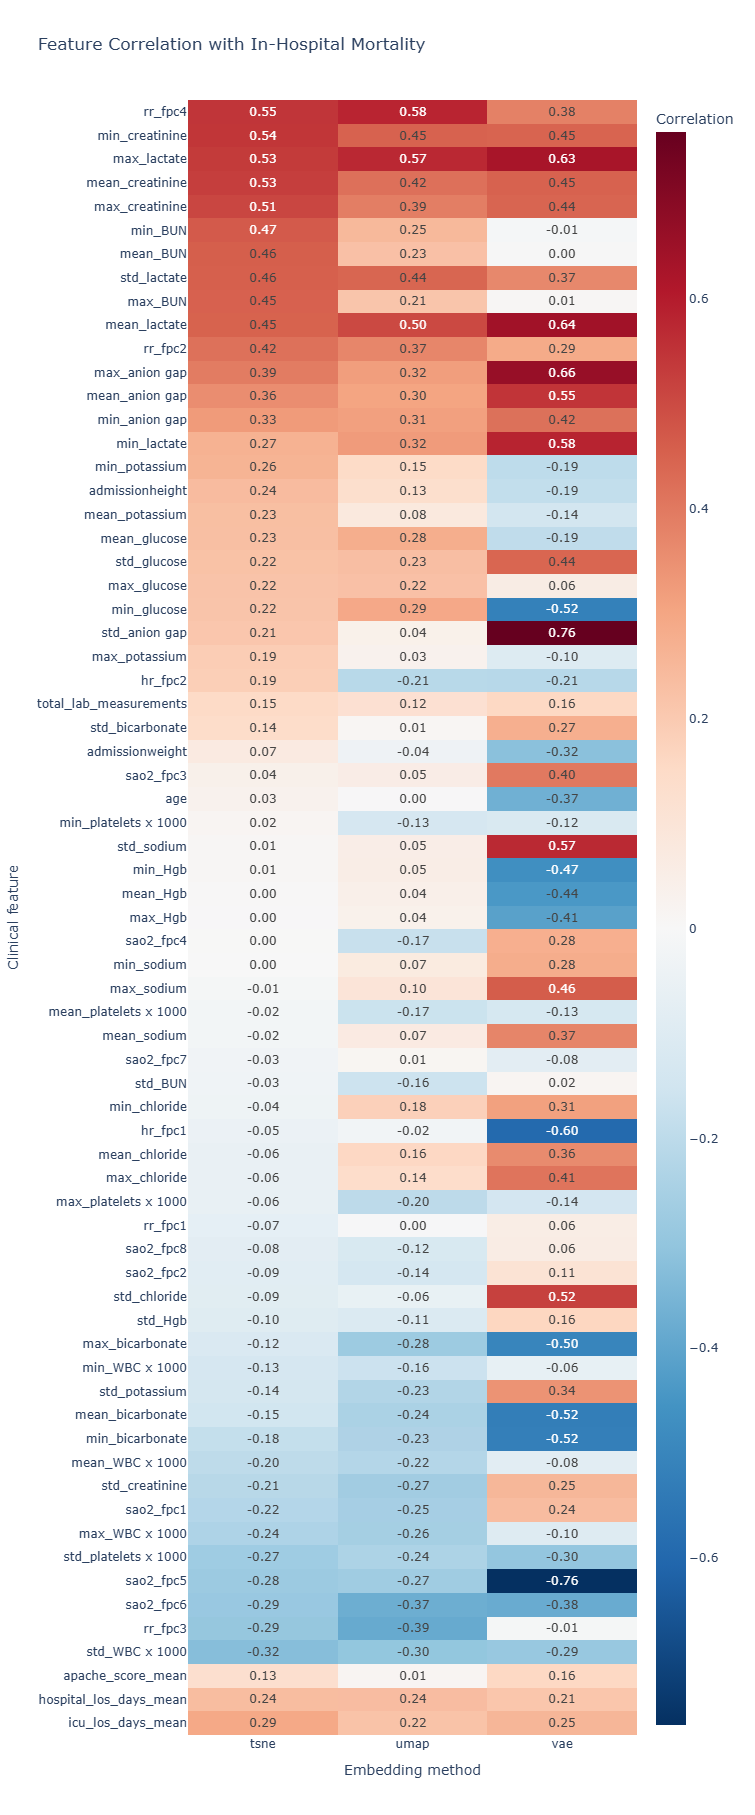

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\feature_mortality_correlation.html


In [74]:
# Add APACHE and LOS correlations to the feature correlation table

extra_wide = (
    extra_corr_df
    .pivot(index="feature", columns="method", values="correlation")
    .reset_index()
)

correlation_plot_data = pd.concat(
    [feature_mortality_correlations, extra_wide],
    ignore_index=True
)

# Create Figure 8 style heatmap

fig = px.imshow(
    correlation_plot_data.set_index("feature")[["tsne", "umap", "vae"]],
    labels=dict(
        x="Embedding method",
        y="Clinical feature",
        color="Correlation"
    ),
    title="Feature Correlation with In-Hospital Mortality",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=0,
    text_auto=".2f"
)

fig.update_layout(
    width=850,
    height=1800
)

fig.show()

# Save interactive figure

fig.write_html(
    PLOTS_DIR / "feature_mortality_correlation.html"
)

print("Saved:", PLOTS_DIR / "feature_mortality_correlation.html")

## SOM hospital mortality map + save 

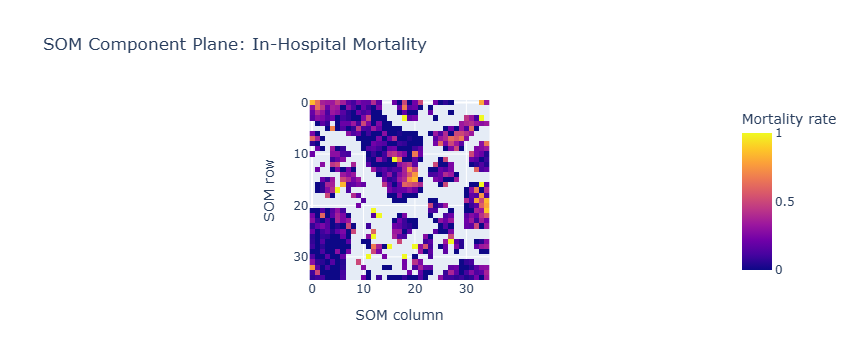

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\som_hospital_mortality.html


In [75]:
# Attach hospital mortality to each patient's SOM location

som_mortality = som_patient_map.merge(
    cohort_outcomes[
        ["patientunitstayid", "hospital_mortality"]
    ],
    on="patientunitstayid",
    how="left"
)

# Calculate mortality rate for each SOM neuron

som_mortality_map = (
    som_mortality
    .groupby(["som_row", "som_col"])["hospital_mortality"]
    .mean()
    .unstack()
    .reindex(
        index=range(SOM_ROWS),
        columns=range(SOM_COLS)
    )
)

# Plot and save

fig = px.imshow(
    som_mortality_map,
    labels=dict(
        x="SOM column",
        y="SOM row",
        color="Mortality rate"
    ),
    title="SOM Component Plane: In-Hospital Mortality",
    aspect="equal"
)

fig.show()

fig.write_html(
    PLOTS_DIR / "som_hospital_mortality.html"
)

print("Saved:", PLOTS_DIR / "som_hospital_mortality.html")

## Prepare t-SNE ICU survival data 

In [76]:
# Prepare t-SNE data for Kaplan-Meier ICU survival analysis

tsne_survival = tsne_cluster_outcomes[
    tsne_cluster_outcomes["cluster"] != -1
][
    ["patientunitstayid", "cluster", "icu_los_days", "icu_mortality"]
].dropna()

print("t-SNE survival dataset shape:", tsne_survival.shape)
print("Number of clusters:", tsne_survival["cluster"].nunique())
print("ICU deaths:", int(tsne_survival["icu_mortality"].sum()))
print("Minimum ICU LOS:", tsne_survival["icu_los_days"].min())
print("Maximum ICU LOS:", tsne_survival["icu_los_days"].max())

t-SNE survival dataset shape: (7203, 4)
Number of clusters: 23
ICU deaths: 924
Minimum ICU LOS: 0.0
Maximum ICU LOS: 246.90416666666667


## Overall log-rank test

In [77]:
tsne_logrank = multivariate_logrank_test(
    tsne_survival["icu_los_days"],
    tsne_survival["cluster"],
    tsne_survival["icu_mortality"]
)

print("Log-rank test statistic:", round(tsne_logrank.test_statistic, 4))
print("Log-rank p-value:", tsne_logrank.p_value)

Log-rank test statistic: 21.3039
Log-rank p-value: 0.5020317990530345


## t-SNE Kaplan-Meier plot + save

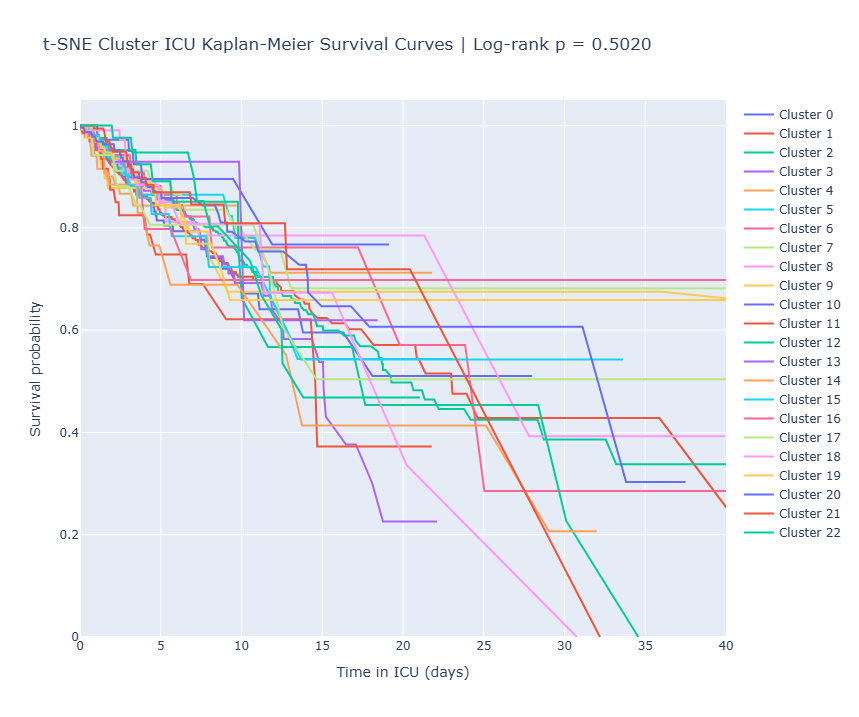

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\tsne_kaplan_meier.html


In [78]:
# Plot t-SNE Kaplan-Meier survival curves

fig = go.Figure()

kmf = KaplanMeierFitter()

for cluster_id in sorted(tsne_survival["cluster"].unique()):

    subset = tsne_survival[
        tsne_survival["cluster"] == cluster_id
    ]

    kmf.fit(
        durations=subset["icu_los_days"],
        event_observed=subset["icu_mortality"],
        label=f"Cluster {cluster_id}"
    )

    survival_curve = kmf.survival_function_

    fig.add_trace(
        go.Scatter(
            x=survival_curve.index,
            y=survival_curve.iloc[:, 0],
            mode="lines",
            name=f"Cluster {cluster_id}"
        )
    )

fig.update_layout(
    title=f"t-SNE Cluster ICU Kaplan-Meier Survival Curves | Log-rank p = {tsne_logrank.p_value:.4f}",
    xaxis_title="Time in ICU (days)",
    yaxis_title="Survival probability",
    xaxis_range=[0, 40],
    yaxis_range=[0, 1.05],
    width=1100,
    height=700
)

fig.show()

fig.write_html(
    PLOTS_DIR / "tsne_kaplan_meier.html"
)

print("Saved:", PLOTS_DIR / "tsne_kaplan_meier.html")

## UMAP survival data + log-rank test

In [79]:
# Prepare UMAP survival data and test survival differences

umap_survival = umap_cluster_outcomes[
    umap_cluster_outcomes["cluster"] != -1
][
    ["patientunitstayid", "cluster", "icu_los_days", "icu_mortality"]
].dropna()

umap_logrank = multivariate_logrank_test(
    umap_survival["icu_los_days"],
    umap_survival["cluster"],
    umap_survival["icu_mortality"]
)

print("Patients:", len(umap_survival))
print("Number of clusters:", umap_survival["cluster"].nunique())
print("ICU deaths:", int(umap_survival["icu_mortality"].sum()))
print("Log-rank test statistic:", round(umap_logrank.test_statistic, 4))
print("Log-rank p-value:", umap_logrank.p_value)

Patients: 7135
Number of clusters: 22
ICU deaths: 914
Log-rank test statistic: 21.8329
Log-rank p-value: 0.40919346621291364


## UMAP Kaplan-Meier plot + save

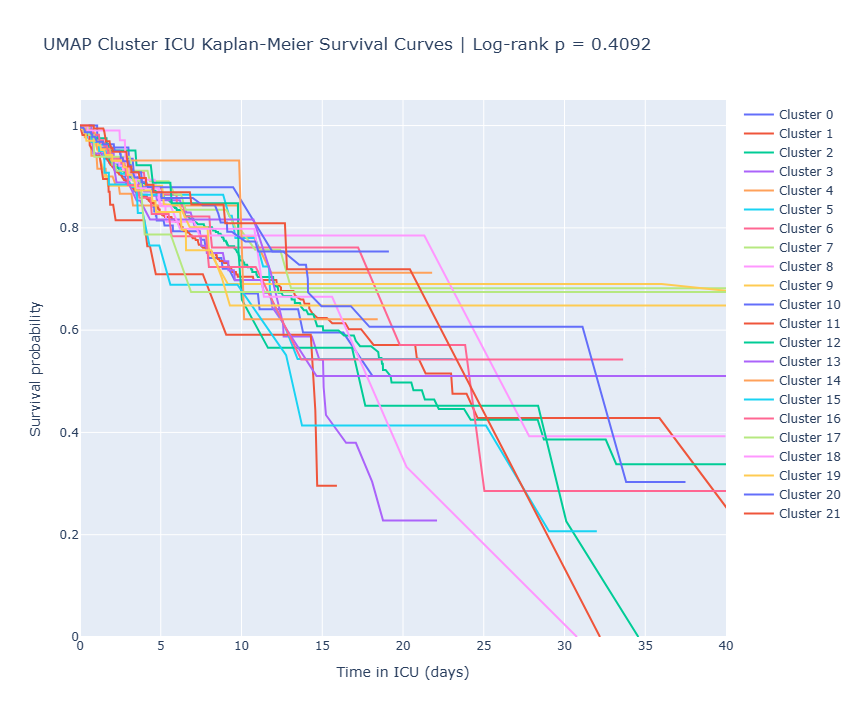

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\umap_kaplan_meier.html


In [80]:
# Plot UMAP Kaplan-Meier survival curves

fig = go.Figure()

kmf = KaplanMeierFitter()

for cluster_id in sorted(umap_survival["cluster"].unique()):

    subset = umap_survival[
        umap_survival["cluster"] == cluster_id
    ]

    kmf.fit(
        durations=subset["icu_los_days"],
        event_observed=subset["icu_mortality"],
        label=f"Cluster {cluster_id}"
    )

    survival_curve = kmf.survival_function_

    fig.add_trace(
        go.Scatter(
            x=survival_curve.index,
            y=survival_curve.iloc[:, 0],
            mode="lines",
            name=f"Cluster {cluster_id}"
        )
    )

fig.update_layout(
    title=f"UMAP Cluster ICU Kaplan-Meier Survival Curves | Log-rank p = {umap_logrank.p_value:.4f}",
    xaxis_title="Time in ICU (days)",
    yaxis_title="Survival probability",
    xaxis_range=[0, 40],
    yaxis_range=[0, 1.05],
    width=1100,
    height=700
)

fig.show()

fig.write_html(
    PLOTS_DIR / "umap_kaplan_meier.html"
)

print("Saved:", PLOTS_DIR / "umap_kaplan_meier.html")

## VAE survival data + log-rank test

In [81]:
# Prepare VAE survival data and test survival differences

vae_survival = vae_cluster_outcomes[
    vae_cluster_outcomes["cluster"] != -1
][
    ["patientunitstayid", "cluster", "icu_los_days", "icu_mortality"]
].dropna()

vae_logrank = multivariate_logrank_test(
    vae_survival["icu_los_days"],
    vae_survival["cluster"],
    vae_survival["icu_mortality"]
)

print("Patients:", len(vae_survival))
print("Number of clusters:", vae_survival["cluster"].nunique())
print("ICU deaths:", int(vae_survival["icu_mortality"].sum()))
print("Log-rank test statistic:", round(vae_logrank.test_statistic, 4))
print("Log-rank p-value:", vae_logrank.p_value)

Patients: 7537
Number of clusters: 11
ICU deaths: 972
Log-rank test statistic: 16.0562
Log-rank p-value: 0.09803443954263427


## VAE Kaplan-Meier plot + save

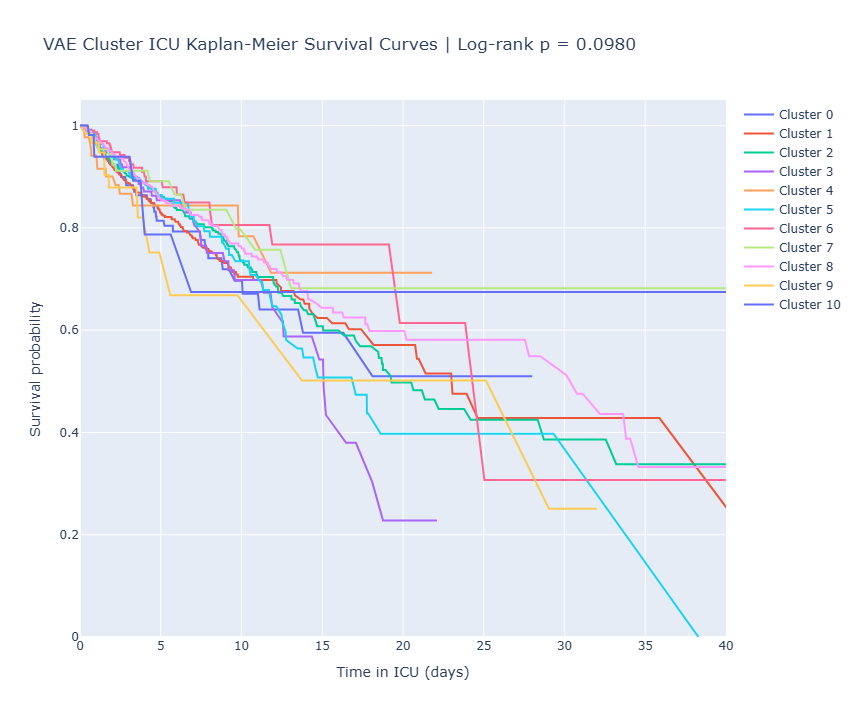

Saved: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\evaluation\vae_kaplan_meier.html


In [82]:
# Plot VAE Kaplan-Meier survival curves

fig = go.Figure()

kmf = KaplanMeierFitter()

for cluster_id in sorted(vae_survival["cluster"].unique()):

    subset = vae_survival[
        vae_survival["cluster"] == cluster_id
    ]

    kmf.fit(
        durations=subset["icu_los_days"],
        event_observed=subset["icu_mortality"],
        label=f"Cluster {cluster_id}"
    )

    survival_curve = kmf.survival_function_

    fig.add_trace(
        go.Scatter(
            x=survival_curve.index,
            y=survival_curve.iloc[:, 0],
            mode="lines",
            name=f"Cluster {cluster_id}"
        )
    )

fig.update_layout(
    title=f"VAE Cluster ICU Kaplan-Meier Survival Curves | Log-rank p = {vae_logrank.p_value:.4f}",
    xaxis_title="Time in ICU (days)",
    yaxis_title="Survival probability",
    xaxis_range=[0, 40],
    yaxis_range=[0, 1.05],
    width=1100,
    height=700
)

fig.show()

fig.write_html(
    PLOTS_DIR / "vae_kaplan_meier.html"
)

print("Saved:", PLOTS_DIR / "vae_kaplan_meier.html")